# Analýza výsledků závodů

Notebook zpracovává výsledky z headless simulace (`--results výsledky.tsv`) a hodnotí **kvalitu každého skriptovaného řidiče** z více hledisek — nejen podle počtu výher.

**Co analyzujeme:**
- Míru dokončení závodu (spolehlivost)
- Rychlost a efektivitu (pro finišery)
- Kolize (bezpečnost jízdy)
- Pokrytí trasy (i pro auta, která nedorazila do cíle)
- Konzistenci výkonu napříč závody
- Celkové skóre (bodovací systém)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tkinter as tk
from tkinter import filedialog

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Otevře dialog pro výběr souboru s výsledky.
root = tk.Tk()
root.withdraw()
root.lift()
root.attributes('-topmost', True)

file_path = filedialog.askopenfilename(
    title='Vyber soubor s výsledky závodů',
    filetypes=[('Textové soubory', '*.txt *.tsv'), ('Všechny soubory', '*.*')]
)
root.destroy()

if not file_path:
    raise SystemExit('Soubor nebyl vybrán.')

print('Načten soubor: ' + file_path)

Načten soubor: C:/Users/daniel.lessner/GitHubRepos/personal-playground/results.txt


In [3]:
# Sloupce odpovídají formátu z --results: Race Time Place Rounds Crashes Distance Avg.speed Car Controller
COLUMNS = ['race', 'time', 'place', 'rounds', 'crashes', 'distance', 'avg_speed', 'car_name', 'controller']

df = pd.read_csv(file_path, sep='\t', header=None, names=COLUMNS)

# "-" v datech označuje DNF — auto závod nedokončilo. Převedeme na NaN.
df['rounds']    = pd.to_numeric(df['rounds'],    errors='coerce')
df['avg_speed'] = pd.to_numeric(df['avg_speed'], errors='coerce')
df['distance']  = pd.to_numeric(df['distance'],  errors='coerce')
df['crashes']   = pd.to_numeric(df['crashes'],   errors='coerce')
df['place']     = pd.to_numeric(df['place'],     errors='coerce')

# Přidáme logický příznak: dokončilo auto závod?
df['finished'] = df['rounds'].notna()

# Seznam unikátních skriptů v pořadí prvního výskytu
controllers = list(df['controller'].unique())

print('Načteno řádků: ' + str(len(df)))
print('Nalezené skripty:')
for ctrl in controllers:
    n_total    = len(df[df['controller'] == ctrl])
    n_finished = len(df[(df['controller'] == ctrl) & (df['finished'] == True)])
    print('  ' + ctrl + ': ' + str(n_total) + ' závodů, ' + str(n_finished) + 'x dokončeno')

df.head(8)

Načteno řádků: 48
Nalezené skripty:
  DijkstraOptimal: 12 závodů, 12x dokončeno
  Dijkstra: 12 závodů, 12x dokončeno
  RandomAuto: 12 závodů, 0x dokončeno
  Teacher: 12 závodů, 0x dokončeno


,race,time,place,rounds,crashes,distance,avg_speed,car_name,controller,finished
0,1,2026-03-11 23:24:29,1,22.0,0,77.8,3.5,DijkstraOptimal,DijkstraOptimal,True
1,1,2026-03-11 23:24:29,2,66.0,0,76.8,1.2,Dijkstra,Dijkstra,True
2,1,2026-03-11 23:24:29,3,NaN,1,22.6,NaN,Random Driver,RandomAuto,False
3,1,2026-03-11 23:24:29,4,NaN,1,17.7,NaN,Driver with a compass,Teacher,False
4,2,2026-03-11 23:24:48,1,15.0,0,60.3,4.0,DijkstraOptimal,DijkstraOptimal,True
5,2,2026-03-11 23:24:48,2,47.0,0,55.3,1.2,Dijkstra,Dijkstra,True
6,2,2026-03-11 23:24:48,3,NaN,1,19.2,NaN,Random Driver,RandomAuto,False
7,2,2026-03-11 23:24:48,4,NaN,1,6.4,NaN,Driver with a compass,Teacher,False


In [4]:
# Konzistentní barvy pro každý skript — použijí se ve všech grafech níže.
PALETTE = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A', '#00838F', '#AD1457', '#F9A825']

controller_colors = {}
for i in range(len(controllers)):
    controller_colors[controllers[i]] = PALETTE[i % len(PALETTE)]

# Pomocná funkce: vrátí seznam barev pro seřazený seznam skriptů.
def colors_for(ctrl_list):
    result = []
    for ctrl in ctrl_list:
        result.append(controller_colors[ctrl])
    return result

# Legenda pro manuální přidání do grafů.
legend_patches = []
for ctrl in controllers:
    patch = mpatches.Patch(color=controller_colors[ctrl], label=ctrl)
    legend_patches.append(patch)

print('Barvy přiřazeny.')

Barvy přiřazeny.


---
## 1. Míra dokončení a průměrné umístění

**Co sledujeme:** Jak často každý skript *vůbec projede cílem*, a jaké průměrné pořadí v závodě dosahuje.

**Proč to důležité:** Algoritmus, který pravidelně havaruje, je v praxi nepoužitelný bez ohledu na teoretickou rychlost. Nulová míra dokončení typicky znamená, že skript neumí vyhýbat kolizím, dostane se do slepé uličky nebo volí pohyby vedoucí mimo trasu.

**Průměrné umístění** doplňuje míru dokončení: auto, které vždy skončí druhé, může mít větší hodnotu než to, co jednou vyhraje a pak pravidelně havaruje.

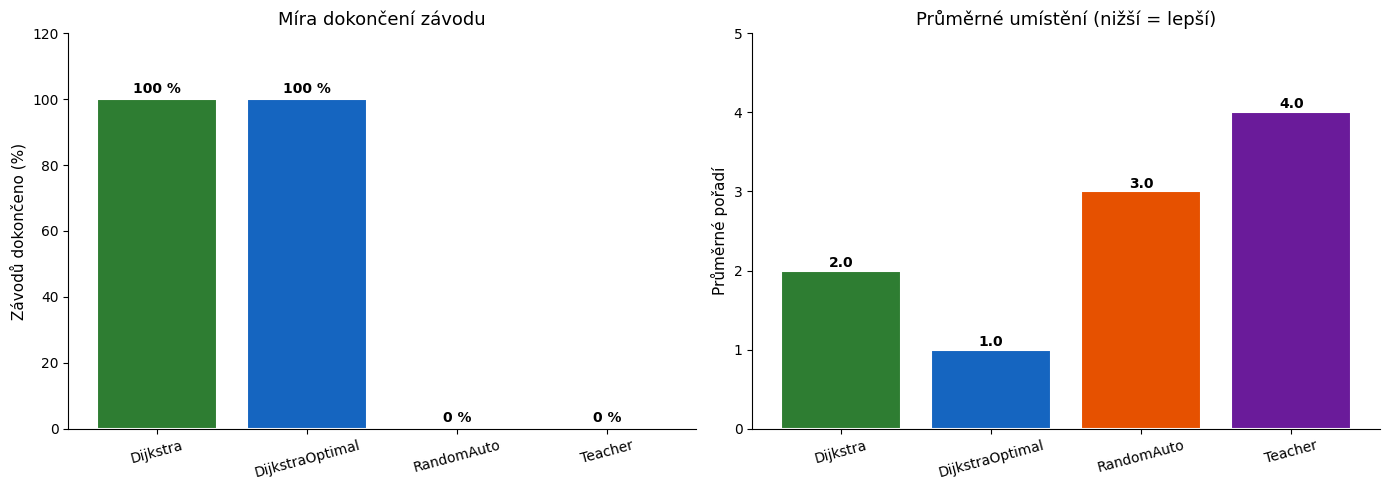

In [5]:
finish_rate = df.groupby('controller')['finished'].mean() * 100
avg_place   = df.groupby('controller')['place'].mean()

ctrl_finish = list(finish_rate.index)
ctrl_place  = list(avg_place.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Míra dokončení ---
finish_vals = list(finish_rate.values)
axes[0].bar(ctrl_finish, finish_vals, color=colors_for(ctrl_finish), edgecolor='white', linewidth=1.5)
axes[0].set_title('Míra dokončení závodu')
axes[0].set_ylabel('Závodů dokončeno (%)')
axes[0].set_ylim(0, 120)
axes[0].tick_params(axis='x', rotation=15)
for i in range(len(ctrl_finish)):
    axes[0].text(i, finish_vals[i] + 2, str(int(finish_vals[i])) + ' %',
                 ha='center', fontweight='bold')

# --- Průměrné umístění ---
place_vals = list(avg_place.values)
axes[1].bar(ctrl_place, place_vals, color=colors_for(ctrl_place), edgecolor='white', linewidth=1.5)
axes[1].set_title('Průměrné umístění (nižší = lepší)')
axes[1].set_ylabel('Průměrné pořadí')
axes[1].set_ylim(0, len(controllers) + 1)
axes[1].tick_params(axis='x', rotation=15)
for i in range(len(ctrl_place)):
    axes[1].text(i, place_vals[i] + 0.05, str(round(place_vals[i], 1)),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 2. Rychlost finišerů

**Co sledujeme:** Pro auta, která závod *dokončila*, sledujeme dvě dimenze rychlosti:

- **Průměrná rychlost** (vzdálenost / počet kol) — měří efektivitu pohybu. Vyšší hodnota = přímější trasa nebo vyšší cestovní rychlost.
- **Počet kol do cíle** — absolutní délka závodu. Méně kol = dřívější příjezd.

**Box plot** zobrazuje: medián (tlustá čára), 25.–75. percentil (obdélník), extrémy (vousy). Úzký obdélník = stabilní výkon, široký = proměnlivý.

*Auta, která závod nedokončila, jsou z tohoto grafu vyloučena — nemají platné hodnoty.*

C:\Users\daniel.lessner\AppData\Local\Temp\ipykernel_97840\3417791066.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(speed_data, labels=speed_labels, patch_artist=True)
C:\Users\daniel.lessner\AppData\Local\Temp\ipykernel_97840\3417791066.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(rounds_data, labels=rounds_labels, patch_artist=True)


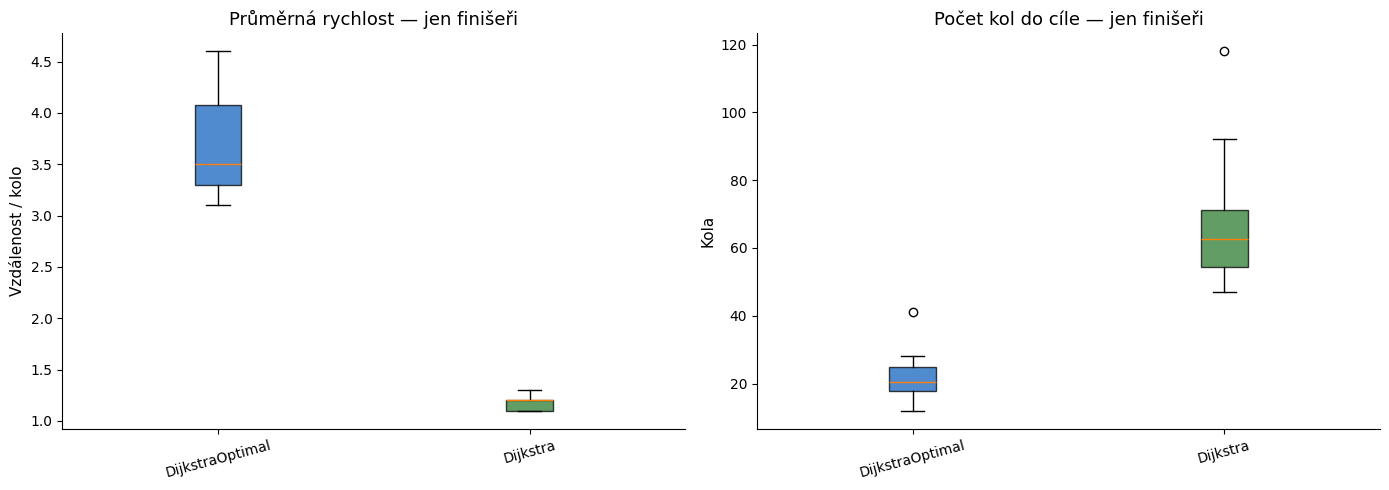

Mediány průměrné rychlosti:
  DijkstraOptimal: 3.5
  Dijkstra: 1.2


In [6]:
finishers = df[df['finished'] == True]

speed_data   = []
speed_labels = []
rounds_data   = []
rounds_labels = []

for ctrl in controllers:
    ctrl_rows = finishers[finishers['controller'] == ctrl]
    if len(ctrl_rows) > 0:
        speed_data.append(list(ctrl_rows['avg_speed']))
        speed_labels.append(ctrl)
        rounds_data.append(list(ctrl_rows['rounds']))
        rounds_labels.append(ctrl)

if len(speed_data) == 0:
    print('Žádný skript nedokončil závod — nelze zobrazit rychlost finišerů.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bp1 = axes[0].boxplot(speed_data, labels=speed_labels, patch_artist=True)
    for i in range(len(bp1['boxes'])):
        bp1['boxes'][i].set_facecolor(controller_colors[speed_labels[i]])
        bp1['boxes'][i].set_alpha(0.75)
    axes[0].set_title('Průměrná rychlost — jen finišeři')
    axes[0].set_ylabel('Vzdálenost / kolo')
    axes[0].tick_params(axis='x', rotation=15)

    bp2 = axes[1].boxplot(rounds_data, labels=rounds_labels, patch_artist=True)
    for i in range(len(bp2['boxes'])):
        bp2['boxes'][i].set_facecolor(controller_colors[rounds_labels[i]])
        bp2['boxes'][i].set_alpha(0.75)
    axes[1].set_title('Počet kol do cíle — jen finišeři')
    axes[1].set_ylabel('Kola')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

    # Výpis mediánů pro rychlé srovnání
    print('Mediány průměrné rychlosti:')
    for i in range(len(speed_labels)):
        vals = speed_data[i]
        vals_sorted = sorted(vals)
        mid = len(vals_sorted) // 2
        if len(vals_sorted) % 2 == 1:
            median = vals_sorted[mid]
        else:
            median = (vals_sorted[mid - 1] + vals_sorted[mid]) / 2
        print('  ' + speed_labels[i] + ': ' + str(round(median, 2)))

---
## 3. Kolize

**Co sledujeme:** Průměrný počet kolizí za závod pro každý skript.

**Proč to důležité:** Kolize způsobují penalizaci — auto stojí na místě několik kol. U skriptů, které závod dokončí, odhalují kolize *riskantní strategie*: auto dorazí do cíle, ale ztrácí čas stáním. Skript s nulovými kolizemi a pomalou rychlostí je konzervativní, ale spolehlivý.

Skript, který pravidelně havaruje *a* závod nedokončí, signalizuje, že kolize jsou přímou příčinou jeho selhání.

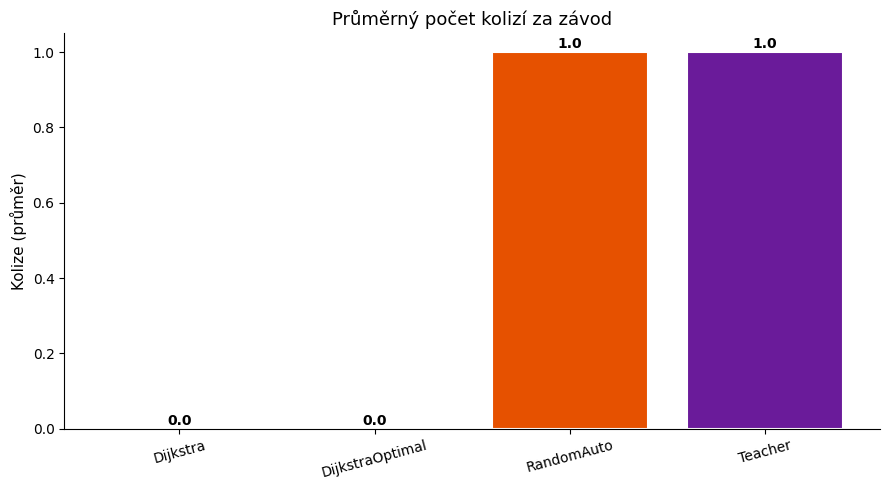

In [7]:
avg_crashes = df.groupby('controller')['crashes'].mean()
crash_ctrls = list(avg_crashes.index)
crash_vals  = list(avg_crashes.values)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(crash_ctrls, crash_vals, color=colors_for(crash_ctrls), edgecolor='white', linewidth=1.5)
ax.set_title('Průměrný počet kolizí za závod')
ax.set_ylabel('Kolize (průměr)')
ax.tick_params(axis='x', rotation=15)
for i in range(len(crash_ctrls)):
    ax.text(i, crash_vals[i] + 0.01, str(round(crash_vals[i], 2)),
            ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Ujetá vzdálenost — absolutní i relativní

**Co sledujeme:** Jak daleko se auto dostalo na trati — včetně aut, která nedojela do cíle.

**Absolutní vzdálenost** závisí na délce konkrétní generované trasy, která se mezi závody mění. Je proto vhodná pro porovnání *v rámci jednoho závodu*, méně pro porovnání přes různé trati.

**Relativní vzdálenost** (% vzdálenosti vítěze v témže závodě) normalizuje rozdíly v délce tratí. Hodnota 100 % = auto ujelo stejně jako vítěz. Hodnota 20 % = auto havariovalo poté, co ujelo pětinu trati vítěze.

Tato metrika je klíčová pro hodnocení DNF aut: odhaluje, zda se auto alespoň dostane do střední části trati, nebo havaruje hned na startu.

C:\Users\daniel.lessner\AppData\Local\Temp\ipykernel_97840\2676394959.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[0].boxplot(abs_data, labels=abs_labels, patch_artist=True)
C:\Users\daniel.lessner\AppData\Local\Temp\ipykernel_97840\2676394959.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp4 = axes[1].boxplot(rel_data, labels=rel_labels, patch_artist=True)


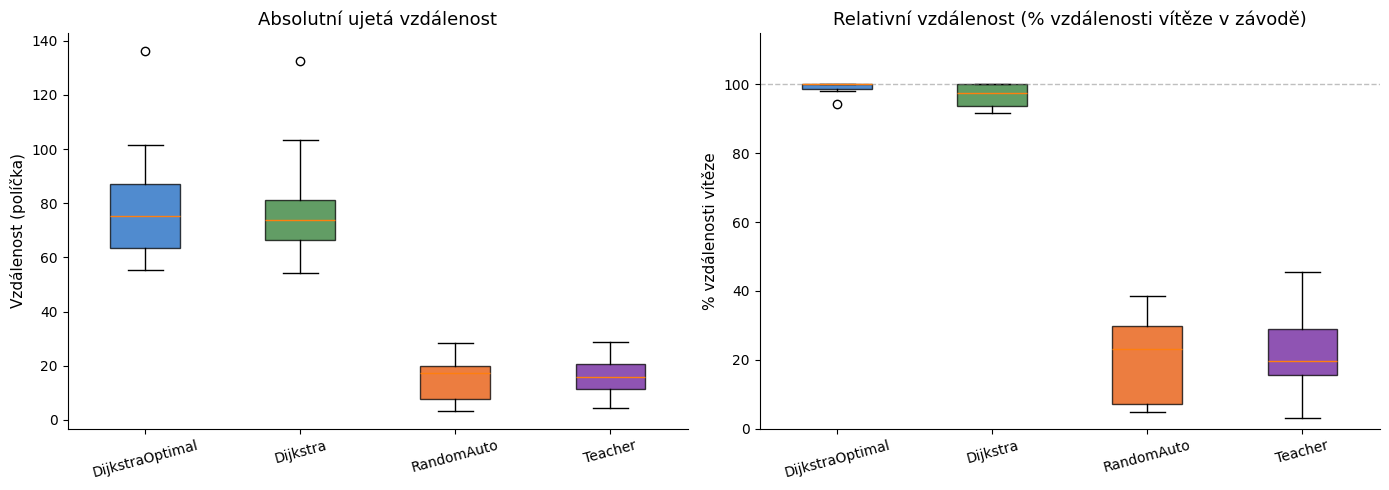

In [8]:
# Unikátní klíč závodu: timestamp + číslo závodu (race ID se resetuje mezi sezeními).
race_keys = []
for i in range(len(df)):
    key = str(df.iloc[i]['time']) + '_' + str(int(df.iloc[i]['race']))
    race_keys.append(key)
df['race_key'] = race_keys

# Maximální vzdálenost dosažená v každém závodě (= vzdálenost vítěze nebo nejdál jedoucího).
unique_keys = list(df['race_key'].unique())
max_dist_by_race = {}
for key in unique_keys:
    race_rows = df[df['race_key'] == key]
    max_dist_by_race[key] = race_rows['distance'].max()

# Relativní vzdálenost = vlastní vzdálenost / max vzdálenost v závodě * 100.
rel_dist_col = []
for i in range(len(df)):
    key   = df.iloc[i]['race_key']
    dist  = df.iloc[i]['distance']
    max_d = max_dist_by_race[key]
    if max_d > 0:
        rel_dist_col.append(dist / max_d * 100)
    else:
        rel_dist_col.append(0.0)
df['relative_dist'] = rel_dist_col

# Připravíme data pro box ploty.
abs_data    = []
abs_labels  = []
rel_data    = []
rel_labels  = []

for ctrl in controllers:
    ctrl_rows = df[df['controller'] == ctrl]
    if len(ctrl_rows) > 0:
        abs_data.append(list(ctrl_rows['distance']))
        abs_labels.append(ctrl)
        rel_data.append(list(ctrl_rows['relative_dist']))
        rel_labels.append(ctrl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp3 = axes[0].boxplot(abs_data, labels=abs_labels, patch_artist=True)
for i in range(len(bp3['boxes'])):
    bp3['boxes'][i].set_facecolor(controller_colors[abs_labels[i]])
    bp3['boxes'][i].set_alpha(0.75)
axes[0].set_title('Absolutní ujetá vzdálenost')
axes[0].set_ylabel('Vzdálenost (políčka)')
axes[0].tick_params(axis='x', rotation=15)

bp4 = axes[1].boxplot(rel_data, labels=rel_labels, patch_artist=True)
for i in range(len(bp4['boxes'])):
    bp4['boxes'][i].set_facecolor(controller_colors[rel_labels[i]])
    bp4['boxes'][i].set_alpha(0.75)
axes[1].set_title('Relativní vzdálenost (% vzdálenosti vítěze v závodě)')
axes[1].set_ylabel('% vzdálenosti vítěze')
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

---
## 5. Konzistence výkonu

**Co sledujeme:** Směrodatnou odchylku průměrné rychlosti a počtu kol u finišerů.

**Proč to důležité:** Dva algoritmy mohou mít stejnou *průměrnou* rychlost, ale jeden ji dosahuje stabilně (malá odchylka), zatímco druhý jednou jede skvěle a jindy stěží dokončí (velká odchylka).

- **Nízká odchylka** → deterministický, předvídatelný algoritmus, který reaguje konzistentně na různé trasy.
- **Vysoká odchylka** → výkon závisí na konkrétním tvaru trasy nebo na náhodě.

*Poznámka: odchylka závisí i na variabilitě tratí. Pokud jsou tratě velmi podobné, bude odchylka přirozeně nižší u všech skriptů.*

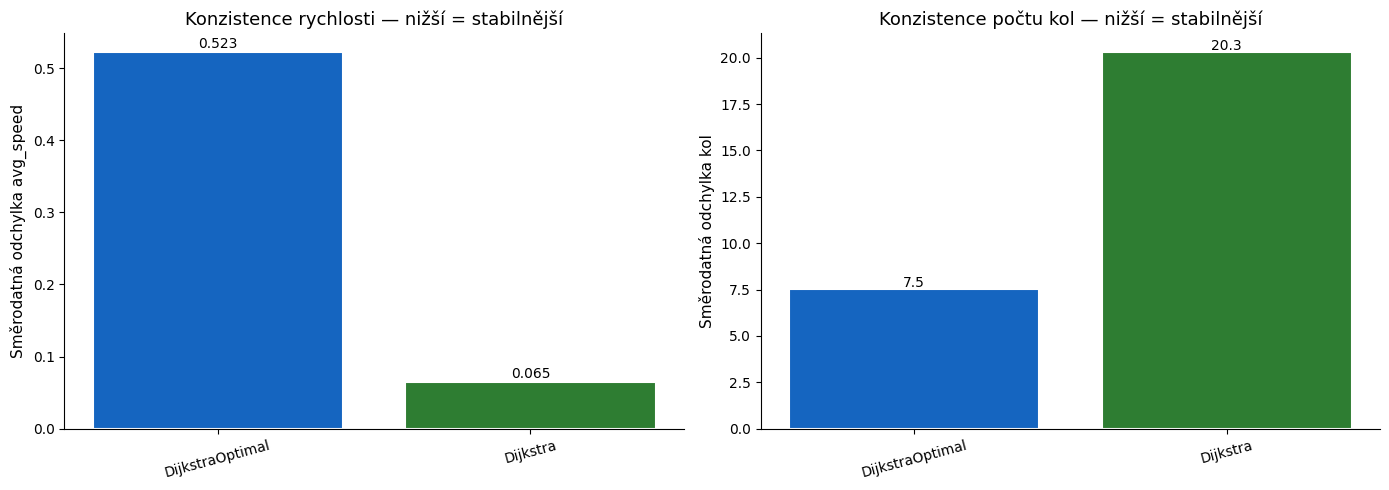

In [9]:
finishers = df[df['finished'] == True]

speed_std_ctrls = []
speed_std_vals  = []
rounds_std_ctrls = []
rounds_std_vals  = []

for ctrl in controllers:
    ctrl_fin = finishers[finishers['controller'] == ctrl]
    if len(ctrl_fin) >= 2:  # směrodatná odchylka potřebuje alespoň 2 hodnoty
        speed_std_ctrls.append(ctrl)
        speed_std_vals.append(ctrl_fin['avg_speed'].std())
        rounds_std_ctrls.append(ctrl)
        rounds_std_vals.append(ctrl_fin['rounds'].std())

if len(speed_std_ctrls) == 0:
    print('Nedostatek dat (potřeba alespoň 2 závody na skript, kde auto dokončilo).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(speed_std_ctrls, speed_std_vals,
                color=colors_for(speed_std_ctrls), edgecolor='white', linewidth=1.5)
    axes[0].set_title('Konzistence rychlosti — nižší = stabilnější')
    axes[0].set_ylabel('Směrodatná odchylka avg_speed')
    axes[0].tick_params(axis='x', rotation=15)
    for i in range(len(speed_std_ctrls)):
        axes[0].text(i, speed_std_vals[i] + 0.005,
                     str(round(speed_std_vals[i], 3)), ha='center')

    axes[1].bar(rounds_std_ctrls, rounds_std_vals,
                color=colors_for(rounds_std_ctrls), edgecolor='white', linewidth=1.5)
    axes[1].set_title('Konzistence počtu kol — nižší = stabilnější')
    axes[1].set_ylabel('Směrodatná odchylka kol')
    axes[1].tick_params(axis='x', rotation=15)
    for i in range(len(rounds_std_ctrls)):
        axes[1].text(i, rounds_std_vals[i] + 0.1,
                     str(round(rounds_std_vals[i], 1)), ha='center')

    plt.tight_layout()
    plt.show()

---
## 6. Bodovací systém (celkové hodnocení)

**Co sledujeme:** Celkové skóre každého skriptu přes všechny závody, inspirované systémem Formule 1.

| Umístění | Body |
|----------|------|
| 1. místo | 10   |
| 2. místo | 7    |
| 3. místo | 5    |
| 4. místo | 3    |
| 5. místo | 2    |
| 6.+ místo | 1   |

**Proč bodový systém?** Prostý počet výher nezachycuje konzistenci. Skript, který skončí druhý v *každém* závodě, může celkově dopadnout lépe než ten, co jednou vyhraje a zbytek závodů nedokončí. Body tak lépe odrážejí souhrnnou kvalitu algoritmu.

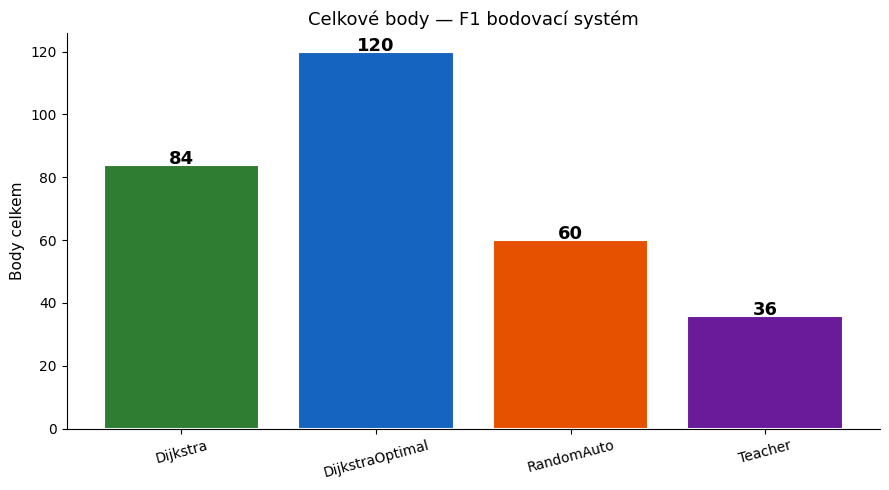

In [10]:
POINTS_MAP = {1: 10, 2: 7, 3: 5, 4: 3, 5: 2}

points_col = []
for i in range(len(df)):
    place_val = df.iloc[i]['place']
    if pd.isna(place_val):
        points_col.append(1)
    else:
        place_int = int(place_val)
        if place_int in POINTS_MAP:
            points_col.append(POINTS_MAP[place_int])
        else:
            points_col.append(1)
df['points'] = points_col

total_points = df.groupby('controller')['points'].sum()
pts_ctrls    = list(total_points.index)
pts_vals     = list(total_points.values)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pts_ctrls, pts_vals, color=colors_for(pts_ctrls), edgecolor='white', linewidth=1.5)
ax.set_title('Celkové body — F1 bodovací systém')
ax.set_ylabel('Body celkem')
ax.tick_params(axis='x', rotation=15)
for i in range(len(pts_ctrls)):
    ax.text(i, pts_vals[i] + 0.3, str(int(pts_vals[i])),
            ha='center', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Souhrnná tabulka

Všechny klíčové metriky na jednom místě pro rychlé srovnání.

In [11]:
finishers = df[df['finished'] == True]

finish_count   = df.groupby('controller')['finished'].sum()
total_count    = df.groupby('controller')['finished'].count()
avg_speed_g    = finishers.groupby('controller')['avg_speed'].mean()
avg_rounds_g   = finishers.groupby('controller')['rounds'].mean()
avg_crashes_g  = df.groupby('controller')['crashes'].mean()
total_points_g = df.groupby('controller')['points'].sum()
avg_rel_dist_g = df.groupby('controller')['relative_dist'].mean()

summary_rows = []
for ctrl in controllers:
    n_total    = int(total_count.get(ctrl, 0))
    n_finished = int(finish_count.get(ctrl, 0))

    if n_total > 0:
        finish_pct = str(round(n_finished / n_total * 100)) + ' %'
    else:
        finish_pct = '–'

    if ctrl in avg_speed_g.index:
        speed_str  = str(round(avg_speed_g[ctrl], 2))
        rounds_str = str(round(avg_rounds_g[ctrl], 1))
    else:
        speed_str  = 'DNF'
        rounds_str = 'DNF'

    row = {
        'Skript':            ctrl,
        'Závodů':            n_total,
        'Dokončení':         finish_pct,
        'Prům. rychlost':    speed_str,
        'Prům. kol':         rounds_str,
        'Prům. kolize':      str(round(avg_crashes_g.get(ctrl, 0), 2)),
        'Relat. vzdál. (%)': str(round(avg_rel_dist_g.get(ctrl, 0), 1)),
        'Body celkem':       int(total_points_g.get(ctrl, 0)),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index('Skript')
summary_df

,Závodů,Dokončení,Prům. rychlost,Prům. kol,Prům. kolize,Relat. vzdál. (%),Body celkem
Skript,,,,,,,
DijkstraOptimal,12,100 %,3.69,22.1,0.0,99.1,120
Dijkstra,12,100 %,1.17,67.4,0.0,96.5,84
RandomAuto,12,0 %,DNF,DNF,1.0,21.0,60
Teacher,12,0 %,DNF,DNF,1.0,21.7,36


---
## Závěr

Notebook hodnotí závodní algoritmy ze šesti různých úhlů pohledu:

| Metrika | Co říká |
|---|---|
| Míra dokončení | Spolehlivost — umí auto vůbec dojet? |
| Průměrná rychlost | Efektivita trasy — jak rychle se pohybuje? |
| Počet kol | Absolutní výkon — jak dlouho závodí? |
| Konzistence | Předvídatelnost — závisí výkon na tvaru trasy? |
| Relativní vzdálenost | Progres DNF aut — jak daleko se dostala? |
| Body (F1) | Celkové hodnocení přes všechny závody |

**Ideální algoritmus** kombinuje:
- vysokou míru dokončení (spolehlivost),
- vysokou průměrnou rychlost (efektivita),
- nízkou odchylku výkonu (konzistence),
- nulové kolize (bezpečnost).

Žádná jediná metrika nestačí — skript, který *vždy vyhraje, ale o fous*, může být méně zajímavý než skript, který vyhraje *s velkým náskokem*, ale občas havaruje.